# HMS - Harmful Brain Activity Classification
## PyTorch Pipeline: nnAudio (Trainable STFT) + EfficientNet + GRU

This notebook implements a full training and inference pipeline that:
1. Loads **raw EEG** signals (no pre-computed spectrograms)
2. Computes spectrograms **on-the-fly** using nnAudio with a trainable STFT
3. Extracts features using a pretrained **EfficientNetV2-B2** backbone
4. Models temporal evolution with a **Bidirectional GRU**
5. Classifies into 6 harmful brain activity categories

### Pipeline
```
Raw EEG [batch, 16, 10000]
    ↓
nnAudio STFT (trainable)
    ↓
Log + Normalize
    ↓
Mono → 3 channel
    ↓
EfficientNet backbone (remove classification head)
    ↓
Pool over frequency, keep time axis
    ↓
GRU reads across time
    ↓
Softmax → 6 classes
```

### Reference
This notebook is the PyTorch counterpart of the Keras starter notebook.
Both can be ensembled at the prediction level (numpy arrays).

# 🛠 | Install Libraries

Run this cell once to install required packages.

In [1]:
# All dependencies are installed via requirements.txt:
#   pip install -r requirements.txt
#
# If running inside the notebook without requirements.txt:
# !pip install -r requirements.txt

# 📚 | Import Libraries

In [2]:
import os
import math
import random
import gc
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
from nnAudio.features import STFT

from sklearn.model_selection import StratifiedGroupKFold
from scipy.signal import butter, sosfiltfilt
import joblib

print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch: 2.10.0+cu128
timm: 1.0.25
CUDA available: True
GPU: Tesla T4


# ⚙️ | Configuration

Mirrors the Keras notebook's CFG class with additions for STFT, GRU,
and differential learning rates.

In [3]:
class CFG:
    # --- General ---
    verbose = 1
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- Data ---
    num_classes = 6
    class_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
    label2name = dict(enumerate(class_names))
    name2label = {v: k for k, v in label2name.items()}

    # --- EEG ---
    eeg_sample_rate = 200       # Hz
    eeg_duration = 50           # seconds
    eeg_samples = eeg_sample_rate * eeg_duration  # 10000
    num_bipolar_channels = 16   # 4 chains x 4 pairs

    # --- Bandpass filter (applied in preprocessing) ---
    bandpass_low = 0.5          # Hz (removes electrode drift)
    bandpass_high = 20.0        # Hz (removes muscle noise)
    bandpass_order = 4          # Butterworth order

    # --- nnAudio STFT ---
    n_fft = 128
    hop_length = 128            # wide view: full 50s
    trainable_stft = True

    # --- Multi-scale STFT ---
    zoom_duration = 10          # seconds for center zoom
    zoom_hop_length = 32        # finer time resolution for zoom

    # --- Frequency crop ---
    freq_crop_hz = 20.0         # crop STFT output to 0-20 Hz (matches bandpass)

    # --- Model ---
    backbone = "tf_efficientnetv2_s"
    gru_hidden = 128
    gru_layers = 1
    dropout = 0.35

    # --- Stage 1: Train on ALL data ---
    epochs_stage1 = 10
    batch_size = 12             # reduced from 16: larger input image
    lr_backbone = 5e-5
    lr_stft = 5e-4
    lr_head = 3e-4
    weight_decay = 1e-4
    max_grad_norm = 1.0

    # --- Stage 2 ---
    epochs_stage2 = 10           # disabled
    lr_stage2_factor = 0.3
    min_votes_stage2 = 10

    # --- Derived ---
    epochs = epochs_stage1

    # --- General Training ---
    lr_mode = "cos"
    use_amp = False
    num_workers = 4
    n_folds = 5
    run_folds = [0, 1, 2, 3, 4]

    # --- Labels ---
    use_soft_labels = True
    label_smoothing = 0.05

    # --- Vote weighting ---
    vote_weight_power = 1.0     # votes^power (0.5=sqrt, 1.0=linear)
    hq_weight_bonus = 2.0       # extra multiplier for HQ samples (>=10 votes)

    # --- SpecAugment ---
    spec_freq_mask = 10
    spec_time_mask = 10
    spec_num_masks = 2

print(f"Device: {CFG.device}")
print(f"Bandpass: {CFG.bandpass_low}-{CFG.bandpass_high} Hz")
print(f"Wide STFT: n_fft={CFG.n_fft}, hop={CFG.hop_length} (full {CFG.eeg_duration}s)")
print(f"Zoom STFT: n_fft={CFG.n_fft}, hop={CFG.zoom_hop_length} (center {CFG.zoom_duration}s)")
print(f"Freq crop: 0-{CFG.freq_crop_hz} Hz")
print(f"Channels: all 16 kept separate (no averaging)")
print(f"Batch size: {CFG.batch_size}")
print(f"LRs: stft={CFG.lr_stft}, backbone={CFG.lr_backbone}, head={CFG.lr_head}")

# Compute expected dimensions
max_bin = int(CFG.freq_crop_hz / (CFG.eeg_sample_rate / CFG.n_fft)) + 1
zoom_samples = CFG.zoom_duration * CFG.eeg_sample_rate
wide_frames = (CFG.eeg_samples - CFG.n_fft) // CFG.hop_length + 1
zoom_frames = (zoom_samples - CFG.n_fft) // CFG.zoom_hop_length + 1
print(f"\nExpected image: [3, {16 * max_bin}, {wide_frames}]")
print(f"  Wide: 16 ch x {max_bin} freq x {wide_frames} time")
print(f"  Zoom: 16 ch x {max_bin} freq x {zoom_frames} time (resized to {wide_frames})")
print(f"Vote weighting: votes^{CFG.vote_weight_power} + {CFG.hq_weight_bonus}x HQ bonus")


Device: cuda
Bandpass: 0.5-20.0 Hz
Wide STFT: n_fft=128, hop=128 (full 50s)
Zoom STFT: n_fft=128, hop=32 (center 10s)
Freq crop: 0-20.0 Hz
Channels: all 16 kept separate (no averaging)
Batch size: 12
LRs: stft=0.0005, backbone=5e-05, head=0.0003

Expected image: [3, 208, 78]
  Wide: 16 ch x 13 freq x 78 time
  Zoom: 16 ch x 13 freq x 59 time (resized to 78)
Vote weighting: votes^1.0 + 2.0x HQ bonus


# ♻️ | Reproducibility

Sets value for random seed to produce similar result in each run.

In [4]:
def set_seed(seed=CFG.seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# 📁 | Dataset Paths

**Important**: Adjust `BASE_PATH` to match your data location.
The Keras notebook uses `project_root.parent.parent / "data" / "data"`.

In [5]:
project_root = Path.cwd()

# =============================================
# ADJUST THIS PATH TO MATCH YOUR DATA LOCATION
# This matches the Keras notebook's path structure
# =============================================
BASE_PATH = project_root.parent.parent.parent / "data" / "data"

# Output directories
MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify
print("=" * 60)
print(f"Project root: {project_root}")
print(f"Data path:    {BASE_PATH}")
print(f"Data exists:  {BASE_PATH.exists()}")

if BASE_PATH.exists():
    for name in ["train.csv", "test.csv", "train_eegs", "test_eegs"]:
        path = BASE_PATH / name
        status = "✓" if path.exists() else "✗"
        print(f"  {status} {name}")
print("=" * 60)

# Pre-processed bipolar EEG files (.npy)
PROCESSED_DIR = BASE_PATH / "processed" / "bipolar_eegs"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Processed EEGs: {PROCESSED_DIR}")


Project root: /home/littl/ECE247A_Final_Project/AL/AL_model
Data path:    /home/littl/data/data
Data exists:  True
  ✓ train.csv
  ✓ test.csv
  ✓ train_eegs
  ✓ test_eegs
Processed EEGs: /home/littl/data/data/processed/bipolar_eegs


# 📖 | Metadata

We only need the EEG paths (not spectrogram paths) since nnAudio
generates spectrograms on-the-fly from raw EEG.

In [6]:
# --- Train ---
df = pd.read_csv(BASE_PATH / "train.csv")
df["eeg_path"] = df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "train_eegs" / f"{x}.parquet")
)
df["class_name"] = df["expert_consensus"].copy()
df["class_label"] = df["expert_consensus"].map(CFG.name2label)

# Soft labels + total votes from expert vote counts
vote_cols = ["seizure_vote", "lpd_vote", "gpd_vote",
             "lrda_vote", "grda_vote", "other_vote"]
if all(c in df.columns for c in vote_cols):
    votes = df[vote_cols].values.astype(np.float32)
    vote_sums = votes.sum(axis=1, keepdims=True)
    vote_sums_safe = np.clip(vote_sums, 1.0, None)
    df["soft_labels"] = (votes / vote_sums_safe).tolist()
    df["total_votes"] = vote_sums.flatten().astype(int)
    print(f"✓ Soft labels created from {vote_cols}")
    print(f"  Total votes distribution:")
    print(f"    min={df['total_votes'].min()}, median={df['total_votes'].median():.0f}, "
          f"max={df['total_votes'].max()}")
    hq_count = (df["total_votes"] >= CFG.min_votes_stage2).sum()
    print(f"  High-quality samples (≥{CFG.min_votes_stage2} votes): {hq_count} "
          f"({hq_count/len(df)*100:.1f}%)")
else:
    df["soft_labels"] = None
    df["total_votes"] = 1
    print("⚠ Vote columns not found — will use one-hot labels")

print(f"\nTrain CSV rows: {len(df)}")
print(f"Unique EEG files: {df['eeg_id'].nunique()}")
print(f"Unique patients: {df['patient_id'].nunique()}")
display(df.head(2))

# --- Test ---
test_df = pd.read_csv(BASE_PATH / "test.csv")
test_df["eeg_path"] = test_df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "test_eegs" / f"{x}.parquet")
)

print(f"\nTest CSV rows: {len(test_df)}")
display(test_df.head(2))

✓ Soft labels created from ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
  Total votes distribution:
    min=1, median=3, max=28
  High-quality samples (≥10 votes): 39946 (37.4%)

Train CSV rows: 106800
Unique EEG files: 17089
Unique patients: 1950


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,eeg_path,class_name,class_label,soft_labels,total_votes
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,Seizure,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]",3
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,Seizure,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]",3



Test CSV rows: 1


,spectrogram_id,eeg_id,patient_id,eeg_path
0,853520,3911565283,6885,/home/littl/data/data/test_eegs/3911565283.par...


# 🧠 | Bipolar Banana Montage

The standard 10-20 system has 19 electrodes. We compute the **double banana bipolar montage**,
which subtracts adjacent electrodes to produce 16 bipolar channels in 4 chains:

| Chain | Pairs | Region |
|-------|-------|--------|
| LL (Left Lateral) | Fp1-F7, F7-T3, T3-T5, T5-O1 | Left temporal |
| RL (Right Lateral) | Fp2-F8, F8-T4, T4-T6, T6-O2 | Right temporal |
| LP (Left Parasagittal) | Fp1-F3, F3-C3, C3-P3, P3-O1 | Left central |
| RP (Right Parasagittal) | Fp2-F4, F4-C4, C4-P4, P4-O2 | Right central |

In [7]:
BIPOLAR_MONTAGE = {
    "LL": [("Fp1", "F7"), ("F7", "T3"), ("T3", "T5"), ("T5", "O1")],
    "RL": [("Fp2", "F8"), ("F8", "T4"), ("T4", "T6"), ("T6", "O2")],
    "LP": [("Fp1", "F3"), ("F3", "C3"), ("C3", "P3"), ("P3", "O1")],
    "RP": [("Fp2", "F4"), ("F4", "C4"), ("C4", "P4"), ("P4", "O2")],
}

BIPOLAR_PAIRS = []
CHAIN_ORDER = ["LL", "RL", "LP", "RP"]
for chain_name in CHAIN_ORDER:
    BIPOLAR_PAIRS.extend(BIPOLAR_MONTAGE[chain_name])

print(f"Total bipolar channels: {len(BIPOLAR_PAIRS)}")
for i, (a, b) in enumerate(BIPOLAR_PAIRS):
    chain = CHAIN_ORDER[i // 4]
    print(f"  Ch {i:2d} ({chain}): {a} - {b}")

# Verify electrode names exist in an actual EEG file
sample_eeg = pd.read_parquet(df.iloc[0]["eeg_path"])
eeg_columns = sample_eeg.columns.tolist()
print(f"\nEEG file columns: {eeg_columns}")
needed = set()
for a, b in BIPOLAR_PAIRS:
    needed.add(a)
    needed.add(b)
missing = needed - set(eeg_columns)
if missing:
    print(f"⚠ WARNING: Missing electrodes: {missing}")
    print("You may need to adjust electrode names in BIPOLAR_MONTAGE")
else:
    print("✓ All required electrodes found in EEG data")

Total bipolar channels: 16
  Ch  0 (LL): Fp1 - F7
  Ch  1 (LL): F7 - T3
  Ch  2 (LL): T3 - T5
  Ch  3 (LL): T5 - O1
  Ch  4 (RL): Fp2 - F8
  Ch  5 (RL): F8 - T4
  Ch  6 (RL): T4 - T6
  Ch  7 (RL): T6 - O2
  Ch  8 (LP): Fp1 - F3
  Ch  9 (LP): F3 - C3
  Ch 10 (LP): C3 - P3
  Ch 11 (LP): P3 - O1
  Ch 12 (RP): Fp2 - F4
  Ch 13 (RP): F4 - C4
  Ch 14 (RP): C4 - P4
  Ch 15 (RP): P4 - O2

EEG file columns: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']
✓ All required electrodes found in EEG data


# 🔄 | Pre-process EEG → Bipolar .npz

One-time conversion: read each raw EEG parquet, compute bipolar montage,
**apply bandpass filter (0.5-20 Hz)**, normalize, and save as .npz.

The bandpass filter:
- **High-pass at 0.5 Hz**: removes slow electrode drift and DC offset
- **Low-pass at 20 Hz**: removes muscle artifact and powerline noise
- This is what top solutions use (2nd place: 0.5-20 Hz)
- Applied BEFORE normalization so the STFT only sees clean signal

⚠️ **If upgrading from v7**: delete old .npz files to re-process with bandpass:
```python
import shutil
shutil.rmtree(str(PROCESSED_DIR))
PROCESSED_DIR.mkdir(exist_ok=True)
```

In [8]:
def bandpass_filter(data, low, high, fs, order=4):
    """Apply zero-phase Butterworth bandpass filter.
    data: [channels, samples]
    Returns filtered data, same shape.
    """
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype='band', output='sos')
    filtered = np.zeros_like(data)
    for i in range(data.shape[0]):
        # Skip dead channels (all zeros or near-zero)
        if np.std(data[i]) > 1e-6:
            try:
                filtered[i] = sosfiltfilt(sos, data[i]).astype(np.float32)
            except ValueError:
                filtered[i] = data[i]  # fallback if signal too short
    return filtered


def preprocess_eeg(row_idx, dataframe, split="train"):
    """Convert one EEG parquet -> pre-processed bipolar .npz file.
    Pipeline: bipolar montage -> clip -> bandpass 0.5-20Hz -> stats -> normalize -> save
    """
    row = dataframe.iloc[row_idx]
    eeg_id = row["eeg_id"]
    output_path = PROCESSED_DIR / f"{eeg_id}.npz"

    if output_path.exists():
        return

    # Load raw EEG
    eeg_df = pd.read_parquet(row["eeg_path"])

    # Extract window
    offset = int(row.get("eeg_label_offset_seconds", 0))
    start = offset * CFG.eeg_sample_rate
    end = start + CFG.eeg_samples
    window = eeg_df.iloc[start:end]

    # Pad if needed
    if len(window) < CFG.eeg_samples:
        pad = pd.DataFrame(
            np.zeros((CFG.eeg_samples - len(window), len(window.columns))),
            columns=window.columns,
        )
        window = pd.concat([window, pad], ignore_index=True)

    # Compute bipolar montage
    cols = window.columns.tolist()
    bipolar = []
    for (a, b) in BIPOLAR_PAIRS:
        if a in cols and b in cols:
            sig = window[a].values - window[b].values
        else:
            sig = np.zeros(CFG.eeg_samples, dtype=np.float32)
        bipolar.append(sig)
    bipolar = np.stack(bipolar, axis=0).astype(np.float32)  # [16, 10000]

    # Clean
    bipolar = np.nan_to_num(bipolar, nan=0.0)
    bipolar = np.clip(bipolar, -1024, 1024)

    # Bandpass filter: 0.5-20 Hz (removes drift + muscle noise)
    bipolar = bandpass_filter(
        bipolar, CFG.bandpass_low, CFG.bandpass_high,
        CFG.eeg_sample_rate, CFG.bandpass_order
    )

    # Compute stats BEFORE normalizing
    chan_mean = bipolar.mean(axis=1).astype(np.float32)  # [16]
    chan_std = bipolar.std(axis=1).astype(np.float32)    # [16]
    stats = np.concatenate([chan_mean, chan_std])          # [32]

    # Normalize per channel
    bipolar = (bipolar - chan_mean[:, None]) / (chan_std[:, None] + 1e-6)

    np.savez_compressed(str(output_path), eeg=bipolar, stats=stats)


# # --- Process training EEGs ---
# unique_train = df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_train)} unique training EEG files...")
# print(f"  Bandpass: {CFG.bandpass_low}-{CFG.bandpass_high} Hz")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_train, "train")
#     for i in tqdm(range(len(unique_train)))
# )

# # --- Process test EEGs ---
# print(f"Processing {len(test_df)} test EEG files...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, test_df, "test")
#     for i in tqdm(range(len(test_df)))
# )

# sample_file = list(PROCESSED_DIR.glob('*.npz'))[0]
# sample_data = np.load(str(sample_file))
# print(f"\n\u2713 Pre-processing complete. Files saved to: {PROCESSED_DIR}")
# print(f"  Sample file size: {sample_file.stat().st_size / 1024:.0f} KB")
# print(f"  EEG shape: {sample_data['eeg'].shape}")
# print(f"  Stats shape: {sample_data['stats'].shape}")


# 🍚 | PyTorch Dataset (Fast .npy Loading)

Loads pre-processed bipolar `.npy` files — no parquet parsing, no cache bloat.
Each `__getitem__` call is a single `np.load()` (~0.5 ms vs ~50 ms for parquet).

**No spectrogram here** — nnAudio computes that inside the model on GPU.

In [9]:
class HMSDataset(Dataset):
    def __init__(self, df, mode="train", augment=False):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.augment = augment
        self.npz_paths = [
            str(PROCESSED_DIR / f"{eid}.npz")
            for eid in self.df["eeg_id"].values
        ]
        # Pre-extract total_votes for fast access
        if "total_votes" in self.df.columns:
            self.total_votes = self.df["total_votes"].values.astype(np.float32)
        else:
            self.total_votes = np.ones(len(self.df), dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def _augment_eeg(self, eeg):
        """Augmentations on normalized EEG signal."""
        noise_std = np.random.uniform(0.005, 0.015)
        eeg = eeg + np.random.normal(0, noise_std, eeg.shape).astype(np.float32)
        scale = np.random.uniform(0.8, 1.2)
        eeg = eeg * scale
        if random.random() < 0.3:
            n_drop = random.randint(1, 2)
            drop_idx = random.sample(range(16), n_drop)
            eeg[drop_idx] = 0.0
        return eeg

    def _get_label(self, idx):
        """
        Get label for sample. Priority:
        1. Soft labels from expert votes (real probability distribution)
        2. One-hot with label smoothing (fallback)
        """
        row = self.df.iloc[idx]

        if CFG.use_soft_labels and row.get("soft_labels") is not None:
            label = np.array(row["soft_labels"], dtype=np.float32)
            return torch.tensor(label, dtype=torch.float32)

        label = torch.zeros(CFG.num_classes, dtype=torch.float32)
        label[int(row["class_label"])] = 1.0

        if CFG.label_smoothing > 0:
            label = label * (1 - CFG.label_smoothing) + CFG.label_smoothing / CFG.num_classes

        return label

    def __getitem__(self, idx):
        data = np.load(self.npz_paths[idx])
        eeg = data["eeg"]        # [16, 10000] normalized
        stats = data["stats"]    # [32] raw channel means + stds

        if self.augment:
            eeg = self._augment_eeg(eeg)

        eeg_tensor = torch.tensor(eeg, dtype=torch.float32)
        stats_tensor = torch.tensor(stats, dtype=torch.float32)
        votes_tensor = torch.tensor(self.total_votes[idx], dtype=torch.float32)

        if self.mode == "test":
            return eeg_tensor, stats_tensor

        label = self._get_label(idx)
        return eeg_tensor, stats_tensor, label, votes_tensor


## MixUp Augmentation

The Keras notebook applies MixUp via `keras_cv.layers.MixUp(alpha=2.0)` on every batch.
Here's the PyTorch equivalent, applied during training.

In [10]:
def mixup(eeg, stats, targets, votes, alpha=2.0):
    """
    MixUp augmentation -- blends pairs of samples.
    Also mixes the vote counts (used for loss weighting).
    """
    if alpha <= 0:
        return eeg, stats, targets, votes

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)  # ensure lam >= 0.5

    batch_size = eeg.size(0)
    index = torch.randperm(batch_size, device=eeg.device)

    eeg = lam * eeg + (1 - lam) * eeg[index]
    stats = lam * stats + (1 - lam) * stats[index]
    targets = lam * targets + (1 - lam) * targets[index]
    votes = lam * votes + (1 - lam) * votes[index]

    return eeg, stats, targets, votes


# 🤖 | Model Architecture (v8)

Major upgrades from v7:
1. **16 channels kept separate** — no more averaging into 4 chains.
   Preserves lateralization info critical for LPD/GPD distinction.
2. **Multi-scale STFT** — wide (50s, hop=128) + zoom (center 10s, hop=32).
   Wide gives context, zoom gives detail on the labeled event.
3. **3-channel input** — [wide, zoom, mean] feeds pretrained backbone.

Architecture:
```
EEG [16, 10000]
  ├─ Wide STFT (hop=128)  → [16, freq, 77]  → stack → [16*freq, 77]
  ├─ Zoom STFT (hop=32)   → [16, freq, 59]  → stack → [16*freq, 59] → resize to 77
  └─ 3ch image: [wide, zoom, mean] → [3, 16*freq, 77]
     → EfficientNet backbone → feature map
     → freq pool + GRU + attention pooling
     → concat with stats MLP
     → classification head → [6]
```

In [11]:
class SpectrogramModel(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.cfg = cfg

        # Frequency crop: how many STFT bins to keep (0 to freq_crop_hz)
        freq_res = cfg.eeg_sample_rate / cfg.n_fft  # Hz per bin
        self.max_bin = int(cfg.freq_crop_hz / freq_res) + 1
        print(f"Freq resolution: {freq_res:.2f} Hz/bin, keeping {self.max_bin} bins (0-{cfg.freq_crop_hz} Hz)")

        # Zoom window: center 10s of 50s clip
        self.zoom_samples = cfg.zoom_duration * cfg.eeg_sample_rate
        self.zoom_start = (cfg.eeg_samples - self.zoom_samples) // 2
        self.zoom_end = self.zoom_start + self.zoom_samples

        # ==============================================================
        # Two STFT layers: wide (context) and zoom (detail)
        # ==============================================================
        self.stft_wide = STFT(
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            sr=cfg.eeg_sample_rate,
            trainable=cfg.trainable_stft,
            output_format="Magnitude",
        )
        self.stft_zoom = STFT(
            n_fft=cfg.n_fft,
            hop_length=cfg.zoom_hop_length,
            sr=cfg.eeg_sample_rate,
            trainable=cfg.trainable_stft,
            output_format="Magnitude",
        )
        self.log_eps = 1e-6

        # ==============================================================
        # CNN backbone (3-channel input: wide, zoom, mean)
        # ==============================================================
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained=True,
            in_chans=3,
            features_only=True,
        )
        # Probe backbone output shape
        img_h = 16 * self.max_bin
        with torch.no_grad():
            dummy = torch.randn(1, 3, img_h, 64)
            backbone_out = self.backbone(dummy)
        backbone_channels = backbone_out[-1].shape[1]
        print(f"Backbone output channels: {backbone_channels}")
        print(f"Input image shape: [3, {img_h}, T]")

        # ==============================================================
        # GRU (1 layer, bidirectional)
        # ==============================================================
        self.gru = nn.GRU(
            input_size=backbone_channels,
            hidden_size=cfg.gru_hidden,
            num_layers=cfg.gru_layers,
            batch_first=True,
            bidirectional=True,
        )

        # ==============================================================
        # Attention pooling over GRU time steps
        # ==============================================================
        gru_out_dim = cfg.gru_hidden * 2
        self.time_attn = nn.Linear(gru_out_dim, 1)

        # ==============================================================
        # Stats side branch
        # ==============================================================
        self.stats_mlp = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(64, 32),
        )

        # ==============================================================
        # Classification head
        # ==============================================================
        self.head = nn.Sequential(
            nn.Dropout(cfg.dropout),
            nn.Linear(gru_out_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(128, cfg.num_classes),
        )

    def _run_stft(self, eeg, stft_layer):
        """Run STFT on all 16 channels, crop frequency, return [batch, 16, freq, time]."""
        batch, channels, time = eeg.shape
        x = eeg.reshape(batch * channels, time)
        x = stft_layer(x)                                 # [B*16, freq_full, T]
        x = x[:, :self.max_bin, :]                         # crop to 0-20 Hz
        freq_bins, time_frames = x.shape[1], x.shape[2]
        x = x.reshape(batch, channels, freq_bins, time_frames)
        return x                                           # [batch, 16, freq, T]

    def _stack_channels(self, spec):
        """Stack 16 channels vertically: [batch, 16, freq, T] -> [batch, 16*freq, T].
        Preserves spatial layout: LL(0-3), RL(4-7), LP(8-11), RP(12-15).
        """
        batch, channels, freq, time = spec.shape
        return spec.reshape(batch, channels * freq, time)  # [batch, 16*freq, T]

    def spec_augment(self, spec):
        """SpecAugment: mask random frequency and time bands. Training only."""
        if not self.training:
            return spec
        batch, freq, time = spec.shape
        for _ in range(self.cfg.spec_num_masks):
            f = random.randint(0, self.cfg.spec_freq_mask)
            f0 = random.randint(0, max(freq - f, 1))
            spec[:, f0:f0+f, :] = 0
            t = random.randint(0, self.cfg.spec_time_mask)
            t0 = random.randint(0, max(time - t, 1))
            spec[:, :, t0:t0+t] = 0
        return spec

    def _log_norm(self, spec):
        """Log + normalize a stacked spectrogram [batch, H, T]."""
        x = torch.log(spec.clamp(min=self.log_eps))
        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True) + 1e-6
        return (x - mean) / std

    def make_multiscale_image(self, eeg):
        """
        Create 3-channel image from wide + zoom STFT of all 16 channels.
        Input:  eeg [batch, 16, 10000]
        Output: img [batch, 3, 16*freq, T_wide]
        """
        # Wide: full 50s context
        spec_wide = self._run_stft(eeg, self.stft_wide)               # [B, 16, freq, T_w]
        wide = self._stack_channels(spec_wide)                         # [B, 16*freq, T_w]
        wide = self._log_norm(wide)                                    # [B, H, T_w]

        # Zoom: center 10s with finer time resolution
        eeg_zoom = eeg[:, :, self.zoom_start:self.zoom_end]            # [B, 16, 2000]
        spec_zoom = self._run_stft(eeg_zoom, self.stft_zoom)          # [B, 16, freq, T_z]
        zoom = self._stack_channels(spec_zoom)                         # [B, 16*freq, T_z]
        zoom = self._log_norm(zoom)                                    # [B, H, T_z]

        # Resize zoom to match wide time dimension
        T_wide = wide.shape[2]
        zoom = F.interpolate(
            zoom.unsqueeze(1),            # [B, 1, H, T_z]
            size=(wide.shape[1], T_wide), # (H, T_w)
            mode='bilinear',
            align_corners=False,
        ).squeeze(1)                      # [B, H, T_w]

        # SpecAugment (on the combined spatial dim)
        wide = self.spec_augment(wide)
        zoom = self.spec_augment(zoom)

        # 3-channel image: [wide context, zoom detail, average]
        mean_spec = (wide + zoom) / 2.0
        img = torch.stack([wide, zoom, mean_spec], dim=1)              # [B, 3, H, T_w]
        return img

    def forward(self, eeg, stats):
        """
        Full pipeline: raw EEG + stats -> class probabilities.
        Input:  eeg   [batch, 16, 10000]
                stats [batch, 32]
        Output: probs [batch, 6]
        """
        # Multi-scale spectrogram image
        img = self.make_multiscale_image(eeg)       # [B, 3, 16*freq, T]

        # CNN backbone
        features = self.backbone(img)
        fmap = features[-1]                          # [B, C, H', W']

        # Pool frequency, keep time for GRU
        x = fmap.mean(dim=2)                         # [B, C, W']
        x = x.permute(0, 2, 1)                      # [B, W', C]

        # GRU across time
        x = x.float()
        x, _ = self.gru(x)                          # [B, W', 256]

        # Attention pooling
        w = torch.softmax(self.time_attn(x), dim=1) # [B, W', 1]
        x = (x * w).sum(dim=1)                      # [B, 256]

        # Side path: stats
        s = self.stats_mlp(stats.float())            # [B, 32]

        # Combine and classify
        combined = torch.cat([x, s], dim=1)          # [B, 288]
        logits = self.head(combined)
        return F.softmax(logits, dim=1)


## Model Sanity Check

Verify shapes at each stage with dummy data.

In [12]:
# Sanity check on CPU only
model_cpu = SpectrogramModel(CFG)

dummy_eeg = torch.randn(2, CFG.num_bipolar_channels, CFG.eeg_samples)
dummy_stats = torch.randn(2, 32)
with torch.no_grad():
    img = model_cpu.make_multiscale_image(dummy_eeg)
    print(f"Multi-scale image:   {img.shape}  (3ch: wide, zoom, mean)")
    feats = model_cpu.backbone(img)
    print(f"Backbone feature map: {feats[-1].shape}")
    fmap = feats[-1]
    pooled = fmap.mean(dim=2)
    print(f"After freq pooling:  {pooled.shape}  (time steps for GRU: {pooled.shape[2]})")
    out = model_cpu(dummy_eeg, dummy_stats)
    print(f"Final output:        {out.shape}")
    print(f"Prob sum (expect 1): {out.sum(dim=1).numpy()}")

total_params = sum(p.numel() for p in model_cpu.parameters())
train_params = sum(p.numel() for p in model_cpu.parameters() if p.requires_grad)
model_size_mb = sum(p.numel() * p.element_size() for p in model_cpu.parameters()) / 1e6
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {train_params:,}")
print(f"Model size:       {model_size_mb:.1f} MB")

del model_cpu, dummy_eeg, dummy_stats, img, feats, fmap, pooled, out
gc.collect()


Freq resolution: 1.56 Hz/bin, keeping 13 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0028 seconds
STFT kernels created, time used = 0.0013 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 256
Input image shape: [3, 208, T]
Multi-scale image:   torch.Size([2, 3, 208, 79])  (3ch: wide, zoom, mean)
Backbone feature map: torch.Size([2, 256, 7, 3])
After freq pooling:  torch.Size([2, 256, 3])  (time steps for GRU: 3)
Final output:        torch.Size([2, 6])
Prob sum (expect 1): [1.         0.99999994]

Total params:     20,219,191
Trainable params: 20,219,191
Model size:       80.9 MB


0

# 🔪 | Data Split

**Identical to Keras notebook**: `StratifiedGroupKFold` with 5 folds,
grouped by `patient_id` to prevent leakage, stratified by `class_label`.

In [13]:
sgkf = StratifiedGroupKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)

df["fold"] = -1
df.reset_index(drop=True, inplace=True)
for fold, (train_idx, valid_idx) in enumerate(
    sgkf.split(df, y=df["class_label"], groups=df["patient_id"])
):
    df.loc[valid_idx, "fold"] = fold

print("Samples per fold and class:")
display(df.groupby(["fold", "class_name"])[["eeg_id"]].count().unstack())

Samples per fold and class:


eeg_id                                
class_name    GPD  GRDA   LPD  LRDA Other Seizure
fold                                             
0            2050  2605  1168  3793  3462    4007
1            4832  4856  4463  3117  3851    4383
2            5386  3389  2658  2432  3598    3711
3            2545  4311  2318  4296  3884    4787
4            1889  3700  4249  3002  4013    4045

## Build Train & Validation Sets

Helper function to create DataLoaders for any fold.
Called inside the training loop for each fold.

In [14]:
sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)

def build_fold_loaders(fold, stage="stage1"):
    """Build train/valid DataLoaders for a given fold and training stage."""
    train_data = sample_df[sample_df.fold != fold].reset_index(drop=True)
    valid_data = sample_df[sample_df.fold == fold].reset_index(drop=True)

    # Stage 2: filter training set to high-quality samples only
    if stage == "stage2":
        train_data = train_data[train_data.total_votes >= CFG.min_votes_stage2].reset_index(drop=True)
        print(f"  Stage 2: {len(train_data)} high-quality train samples "
              f"(≥{CFG.min_votes_stage2} votes)")

    train_dataset = HMSDataset(train_data, mode="train", augment=True)
    valid_dataset = HMSDataset(valid_data, mode="valid", augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG.batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=True,
        drop_last=True,
        persistent_workers=True if CFG.num_workers > 0 else False,
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=CFG.batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=True,
        drop_last=False,
        persistent_workers=True if CFG.num_workers > 0 else False,
    )
    return train_loader, valid_loader, valid_data

# Quick check
train_loader, valid_loader, _ = build_fold_loaders(0, stage="stage1")
print(f"Fold 0 Stage 1: {len(train_loader)} train batches, {len(valid_loader)} valid batches")
train_loader_s2, _, _ = build_fold_loaders(0, stage="stage2")
print(f"Fold 0 Stage 2: {len(train_loader_s2)} train batches (high-quality only)")
del train_loader_s2

Fold 0 Stage 1: 763 train batches, 165 valid batches
  Stage 2: 3325 high-quality train samples (≥10 votes)
Fold 0 Stage 2: 277 train batches (high-quality only)


## Dataset Sanity Check

In [15]:
sample_eeg, sample_stats, sample_label, sample_votes = next(iter(train_loader))
print(f"EEG batch:    {sample_eeg.shape}")
print(f"Stats batch:  {sample_stats.shape}")
print(f"Labels batch: {sample_label.shape}")
print(f"Votes batch:  {sample_votes.shape}")
print(f"Votes range:  {sample_votes.min():.0f} - {sample_votes.max():.0f}")
print(f"\nSample label (soft): {sample_label[0].numpy()}")
print(f"Sample votes: {sample_votes[0].item():.0f}")

EEG batch:    torch.Size([12, 16, 10000])
Stats batch:  torch.Size([12, 32])
Labels batch: torch.Size([12, 6])
Votes batch:  torch.Size([12])
Votes range:  1 - 18

Sample label (soft): [0. 0. 0. 0. 0. 1.]
Sample votes: 18


# 🔍 | Loss Function

KL Divergence — same as `keras.losses.KLDivergence()` in the Keras notebook.

In [16]:
class KLDivLoss(nn.Module):
    """
    KL Divergence loss with per-sample weighting by annotator count.

    Two mechanisms to emphasize high-quality samples:
    1. votes^power: continuous weighting (power=1.0 means linear in vote count)
    2. hq_weight_bonus: discrete 2x multiplier for samples with >=10 votes

    Combined effect (with power=1.0, bonus=2.0):
        3 votes  -> weight  3.0 * 1.0 =  3.0  (normalized ~0.45)
        7 votes  -> weight  7.0 * 1.0 =  7.0  (normalized ~1.05)
       10 votes  -> weight 10.0 * 2.0 = 20.0  (normalized ~3.00)
       20 votes  -> weight 20.0 * 2.0 = 40.0  (normalized ~6.00)

    High-quality samples dominate the gradient, which is what we want:
    they have reliable labels AND they're what the LB evaluates on.
    """
    def __init__(self, cfg=CFG):
        super().__init__()
        self.loss_fn = nn.KLDivLoss(reduction="none")
        self.power = cfg.vote_weight_power
        self.hq_bonus = cfg.hq_weight_bonus

    def forward(self, preds, targets, votes=None):
        per_sample = self.loss_fn(
            torch.log(preds.clamp(min=1e-8)), targets
        ).sum(dim=1)

        if votes is not None:
            # Continuous: votes^power
            weights = votes.clamp(min=1.0) ** self.power

            # Discrete: bonus for HQ samples (>=10 votes)
            if self.hq_bonus > 1.0:
                hq_mask = votes >= 10.0
                weights[hq_mask] = weights[hq_mask] * self.hq_bonus

            # Normalize so mean weight = 1 (preserves loss scale)
            weights = weights / weights.mean()
            return (per_sample * weights).mean()
        else:
            return per_sample.mean()

criterion = KLDivLoss(CFG)
print(f"Loss: KL-Div weighted by votes^{CFG.vote_weight_power} + {CFG.hq_weight_bonus}x HQ bonus")


Loss: KL-Div weighted by votes^1.0 + 2.0x HQ bonus


# ⚓ | Optimizer & LR Schedule

**Differential learning rates** — the Keras notebook uses a single LR for everything.
Here we use separate rates because our model has components at different training maturity:
- STFT: learning from scratch → highest LR
- Backbone: pretrained ImageNet → lowest LR
- GRU + head: new layers → medium LR

The schedule shape matches the Keras notebook: linear warmup → cosine decay.

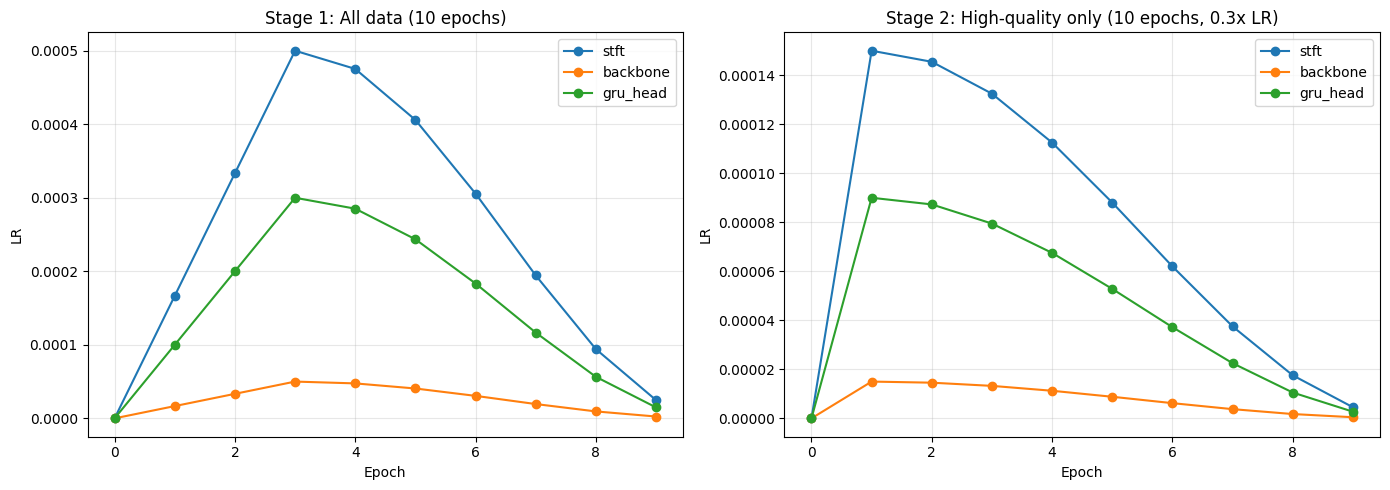

In [17]:
def build_optimizer(model, cfg=CFG, stage="stage1"):
    """AdamW with differential learning rates per component."""
    lr_factor = 1.0 if stage == "stage1" else cfg.lr_stage2_factor
    return torch.optim.AdamW([
        {"params": list(model.stft_wide.parameters())
                 + list(model.stft_zoom.parameters()),
         "lr": cfg.lr_stft * lr_factor, "name": "stft"},
        {"params": model.backbone.parameters(),
         "lr": cfg.lr_backbone * lr_factor, "name": "backbone"},
        {"params": list(model.gru.parameters())
                 + list(model.stats_mlp.parameters())
                 + list(model.head.parameters()),
         "lr": cfg.lr_head * lr_factor, "name": "gru_head"},
    ], weight_decay=cfg.weight_decay)


def get_cosine_schedule(optimizer, epochs, warmup_epochs=3):
    """Cosine annealing with linear warmup."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# --- Visualize 2-stage LR schedule ---
lr_names = ["stft", "backbone", "gru_head"]
lr_bases = [CFG.lr_stft, CFG.lr_backbone, CFG.lr_head]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Stage 1
for name, base_lr in zip(lr_names, lr_bases):
    lrs = []
    for e in range(CFG.epochs_stage1):
        if e < 3:
            factor = e / 3
        else:
            progress = (e - 3) / (CFG.epochs_stage1 - 3)
            factor = 0.5 * (1 + math.cos(math.pi * progress))
        lrs.append(base_lr * factor)
    ax1.plot(lrs, marker="o", label=name)
ax1.set_title(f"Stage 1: All data ({CFG.epochs_stage1} epochs)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("LR"); ax1.legend(); ax1.grid(True, alpha=0.3)

# Stage 2
for name, base_lr in zip(lr_names, lr_bases):
    s2_base = base_lr * CFG.lr_stage2_factor
    lrs = []
    warmup = 1  # shorter warmup for stage 2
    for e in range(CFG.epochs_stage2):
        if e < warmup:
            factor = e / warmup
        else:
            progress = (e - warmup) / (CFG.epochs_stage2 - warmup)
            factor = 0.5 * (1 + math.cos(math.pi * progress))
        lrs.append(s2_base * factor)
    ax2.plot(lrs, marker="o", label=name)
ax2.set_title(f"Stage 2: High-quality only ({CFG.epochs_stage2} epochs, {CFG.lr_stage2_factor}x LR)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("LR"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🚂 | Training & Validation Functions

Includes:
- **Mixed precision** (`autocast` + `GradScaler`) — PyTorch equivalent of Keras `mixed_float16`
- **MixUp** on every training batch — matches Keras notebook's always-on augmentation
- **Gradient clipping** — essential for GRU stability

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch,
                    total_epochs=20, cfg=CFG):
    """Train one epoch with MixUp, vote-weighted loss, and stats side features."""
    model.train()
    scaler = GradScaler(enabled=cfg.use_amp)
    running_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch+1}/{total_epochs}")
    for eeg, stats, labels, votes in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        votes = votes.to(device, non_blocking=True)

        eeg, stats, labels, votes = mixup(eeg, stats, labels, votes, alpha=2.0)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            loss = criterion(preds, labels, votes=votes)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        num_batches += 1

        gpu_gb = torch.cuda.memory_allocated() / 1e9
        pbar.set_postfix({
            "loss": f"{running_loss / num_batches:.4f}",
            "gpu": f"{gpu_gb:.1f}GB"
        })

    return running_loss / num_batches


@torch.no_grad()
def validate(model, loader, criterion, device, epoch,
             total_epochs=20, cfg=CFG):
    """
    Validate one epoch with split metrics by annotator quality.
    Returns: (val_loss_all, val_loss_hq, val_loss_lq)
    """
    model.eval()
    all_losses = []
    all_votes = []

    pbar = tqdm(loader, desc=f"Valid Epoch {epoch+1}/{total_epochs}")
    for eeg, stats, labels, votes in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            # Per-sample loss (no weighting for validation — we want true metric)
            per_sample = nn.KLDivLoss(reduction="none")(
                torch.log(preds.clamp(min=1e-8)), labels
            ).sum(dim=1)

        all_losses.append(per_sample.cpu())
        all_votes.append(votes)

        # Running average for progress bar
        running_mean = torch.cat(all_losses).mean().item()
        pbar.set_postfix({"val_loss": f"{running_mean:.4f}"})

    # Combine all batches
    all_losses = torch.cat(all_losses)
    all_votes = torch.cat(all_votes)

    # Split by quality
    hq_mask = all_votes >= 10
    lq_mask = ~hq_mask

    val_loss_all = all_losses.mean().item()
    val_loss_hq = all_losses[hq_mask].mean().item() if hq_mask.any() else float("nan")
    val_loss_lq = all_losses[lq_mask].mean().item() if lq_mask.any() else float("nan")

    n_hq = hq_mask.sum().item()
    n_lq = lq_mask.sum().item()
    print(f"  val_loss: ALL={val_loss_all:.4f} | "
          f"HQ={val_loss_hq:.4f} ({n_hq} samples) | "
          f"LQ={val_loss_lq:.4f} ({n_lq} samples)")

    return val_loss_all, val_loss_hq, val_loss_lq


# 🏋️ | 5-Fold Cross-Validation + 2-Stage Training

For each fold:
- **Stage 1** (20 epochs): Train on ALL training data with cosine LR schedule
- **Stage 2** (10 epochs): Fine-tune on high-quality samples (≥10 expert votes) with reduced LR

This follows the 1st place solution's approach: the model learns general
patterns first, then specializes on the most reliable annotations.

## Training Loop

The model is created fresh for each fold. Only ONE model lives on GPU at a time.

In [19]:
def train_fold(fold, cfg=CFG):
    """
    Train one fold. Reports split metrics: ALL / HQ (>=10 votes) / LQ (<10 votes).
    The HQ metric is what correlates with the Kaggle LB.
    """
    print(f"\n{'='*60}")
    print(f"FOLD {fold}")
    print(f"{'='*60}")

    gc.collect()
    torch.cuda.empty_cache()
    set_seed(cfg.seed + fold)

    model = SpectrogramModel(cfg).to(cfg.device)
    print(f"GPU after model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    checkpoint_path = str(MODELS_DIR / f"best_model_fold{fold}.pt")
    history = {
        "train_loss": [], "val_loss": [], "val_loss_hq": [], "val_loss_lq": [],
        "lr": [], "stage": []
    }
    best_val_loss_hq = float("inf")
    best_val_loss_all = float("inf")
    best_epoch = -1

    # ==============================================================
    # STAGE 1: Train on ALL data
    # ==============================================================
    print(f"\n--- Stage 1: All data, {cfg.epochs_stage1} epochs ---")
    train_loader, valid_loader, _ = build_fold_loaders(fold, stage="stage1")
    optimizer = build_optimizer(model, cfg, stage="stage1")
    scheduler = get_cosine_schedule(optimizer, cfg.epochs_stage1, warmup_epochs=3)

    for epoch in range(cfg.epochs_stage1):
        current_lrs = {pg["name"]: f"{pg['lr']:.2e}" for pg in optimizer.param_groups}
        print(f"\n[S1] Epoch {epoch+1}/{cfg.epochs_stage1} | LRs: {current_lrs}")

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, cfg.device, epoch,
            total_epochs=cfg.epochs_stage1)
        val_loss_all, val_loss_hq, val_loss_lq = validate(
            model, valid_loader, criterion, cfg.device, epoch,
            total_epochs=cfg.epochs_stage1)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss_all)
        history["val_loss_hq"].append(val_loss_hq)
        history["val_loss_lq"].append(val_loss_lq)
        history["lr"].append(optimizer.param_groups[1]["lr"])
        history["stage"].append(1)

        # Save based on HQ val_loss (correlates with LB)
        if val_loss_hq < best_val_loss_hq:
            best_val_loss_hq = val_loss_hq
            best_val_loss_all = val_loss_all
            best_epoch = epoch
            torch.save({
                "epoch": epoch, "stage": 1,
                "model_state_dict": model.state_dict(),
                "val_loss": val_loss_all,
                "val_loss_hq": val_loss_hq,
                "val_loss_lq": val_loss_lq,
            }, checkpoint_path)
            print(f"  \u2713 Best model saved (HQ: {val_loss_hq:.4f}, ALL: {val_loss_all:.4f})")
        else:
            print(f"  HQ: {val_loss_hq:.4f} (best: {best_val_loss_hq:.4f} @ epoch {best_epoch+1})")

    print(f"\nStage 1 done. Best HQ val_loss: {best_val_loss_hq:.4f}")

    # ==============================================================
    # STAGE 2 (skip if epochs_stage2 == 0)
    # ==============================================================
    if cfg.epochs_stage2 > 0:
        print(f"\n--- Stage 2: High-quality data, {cfg.epochs_stage2} epochs ---")
        ckpt = torch.load(checkpoint_path, map_location=cfg.device)
        model.load_state_dict(ckpt["model_state_dict"])

        train_loader_s2, valid_loader, _ = build_fold_loaders(fold, stage="stage2")
        optimizer_s2 = build_optimizer(model, cfg, stage="stage2")
        scheduler_s2 = get_cosine_schedule(optimizer_s2, cfg.epochs_stage2, warmup_epochs=1)

        for epoch in range(cfg.epochs_stage2):
            current_lrs = {pg["name"]: f"{pg['lr']:.2e}" for pg in optimizer_s2.param_groups}
            print(f"\n[S2] Epoch {epoch+1}/{cfg.epochs_stage2} | LRs: {current_lrs}")

            train_loss = train_one_epoch(
                model, train_loader_s2, optimizer_s2, criterion, cfg.device, epoch,
                total_epochs=cfg.epochs_stage2)
            val_loss_all, val_loss_hq, val_loss_lq = validate(
                model, valid_loader, criterion, cfg.device, epoch,
                total_epochs=cfg.epochs_stage2)
            scheduler_s2.step()

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss_all)
            history["val_loss_hq"].append(val_loss_hq)
            history["val_loss_lq"].append(val_loss_lq)
            history["lr"].append(optimizer_s2.param_groups[1]["lr"])
            history["stage"].append(2)

            if val_loss_hq < best_val_loss_hq:
                best_val_loss_hq = val_loss_hq
                best_val_loss_all = val_loss_all
                best_epoch = cfg.epochs_stage1 + epoch
                torch.save({
                    "epoch": best_epoch, "stage": 2,
                    "model_state_dict": model.state_dict(),
                    "val_loss": val_loss_all,
                    "val_loss_hq": val_loss_hq,
                    "val_loss_lq": val_loss_lq,
                }, checkpoint_path)
                print(f"  \u2713 Best model saved (HQ: {val_loss_hq:.4f})")
            else:
                print(f"  HQ: {val_loss_hq:.4f} (best: {best_val_loss_hq:.4f})")

        del optimizer_s2, scheduler_s2, train_loader_s2

    # Cleanup
    del model, optimizer, scheduler, train_loader, valid_loader
    gc.collect()
    torch.cuda.empty_cache()

    print(f"\nFold {fold} done. Best: HQ={best_val_loss_hq:.4f}, ALL={best_val_loss_all:.4f}")
    return {"all": best_val_loss_all, "hq": best_val_loss_hq}, history


# ==============================================================
# Run all folds
# ==============================================================
fold_results = {}
all_histories = {}

for fold in CFG.run_folds:
    try:
        results, history = train_fold(fold)
        fold_results[fold] = results
        all_histories[fold] = history
    except RuntimeError as e:
        print(f"\n\u2717 Fold {fold} failed: {e}")
        if "out of memory" in str(e).lower():
            print("  \u2192 Restart kernel, reduce batch_size")
        gc.collect()
        torch.cuda.empty_cache()
        break

# ==============================================================
# Summary with HQ/LQ split
# ==============================================================
print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"  {'Fold':<8} {'ALL':>10} {'HQ (>=10v)':>12} {'(=LB est.)':>12}")
print(f"  {'-'*8} {'-'*10} {'-'*12} {'-'*12}")
for fold, res in fold_results.items():
    print(f"  Fold {fold:<3} {res['all']:>10.4f} {res['hq']:>12.4f}")
if fold_results:
    cv_all = np.mean([r["all"] for r in fold_results.values()])
    cv_hq = np.mean([r["hq"] for r in fold_results.values()])
    cv_all_std = np.std([r["all"] for r in fold_results.values()])
    cv_hq_std = np.std([r["hq"] for r in fold_results.values()])
    print(f"  {'-'*8} {'-'*10} {'-'*12}")
    print(f"  {'CV':<8} {cv_all:>10.4f} {cv_hq:>12.4f}")
    print(f"  {'  +/-':<8} {cv_all_std:>10.4f} {cv_hq_std:>12.4f}")
    print(f"\n  \u2192 HQ CV ({cv_hq:.4f}) is your best estimate of LB score")



FOLD 0
Freq resolution: 1.56 Hz/bin, keeping 13 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0018 seconds
STFT kernels created, time used = 0.0013 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 256
Input image shape: [3, 208, T]
GPU after model: 0.08 GB

--- Stage 1: All data, 10 epochs ---

[S1] Epoch 1/10 | LRs: {'stft': '0.00e+00', 'backbone': '0.00e+00', 'gru_head': '0.00e+00'}


/var/tmp/ipykernel_714870/908567103.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.use_amp)


Train Epoch 1/10:   0%|          | 0/763 [00:00<?, ?it/s]

...

  val_loss: ALL=0.9239 | HQ=0.4181 (911 samples) | LQ=1.2446 (1437 samples)
  HQ: 0.4181 (best: 0.4178)

Fold 2 done. Best: HQ=0.4178, ALL=0.9385

FOLD 3
Freq resolution: 1.56 Hz/bin, keeping 13 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0039 seconds
STFT kernels created, time used = 0.0012 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 256
Input image shape: [3, 208, T]
GPU after model: 0.10 GB

--- Stage 1: All data, 10 epochs ---

[S1] Epoch 1/10 | LRs: {'stft': '0.00e+00', 'backbone': '0.00e+00', 'gru_head': '0.00e+00'}


Train Epoch 1/10:   0%|          | 0/740 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Training History (All Folds)

NameError: name 'cv_all' is not defined

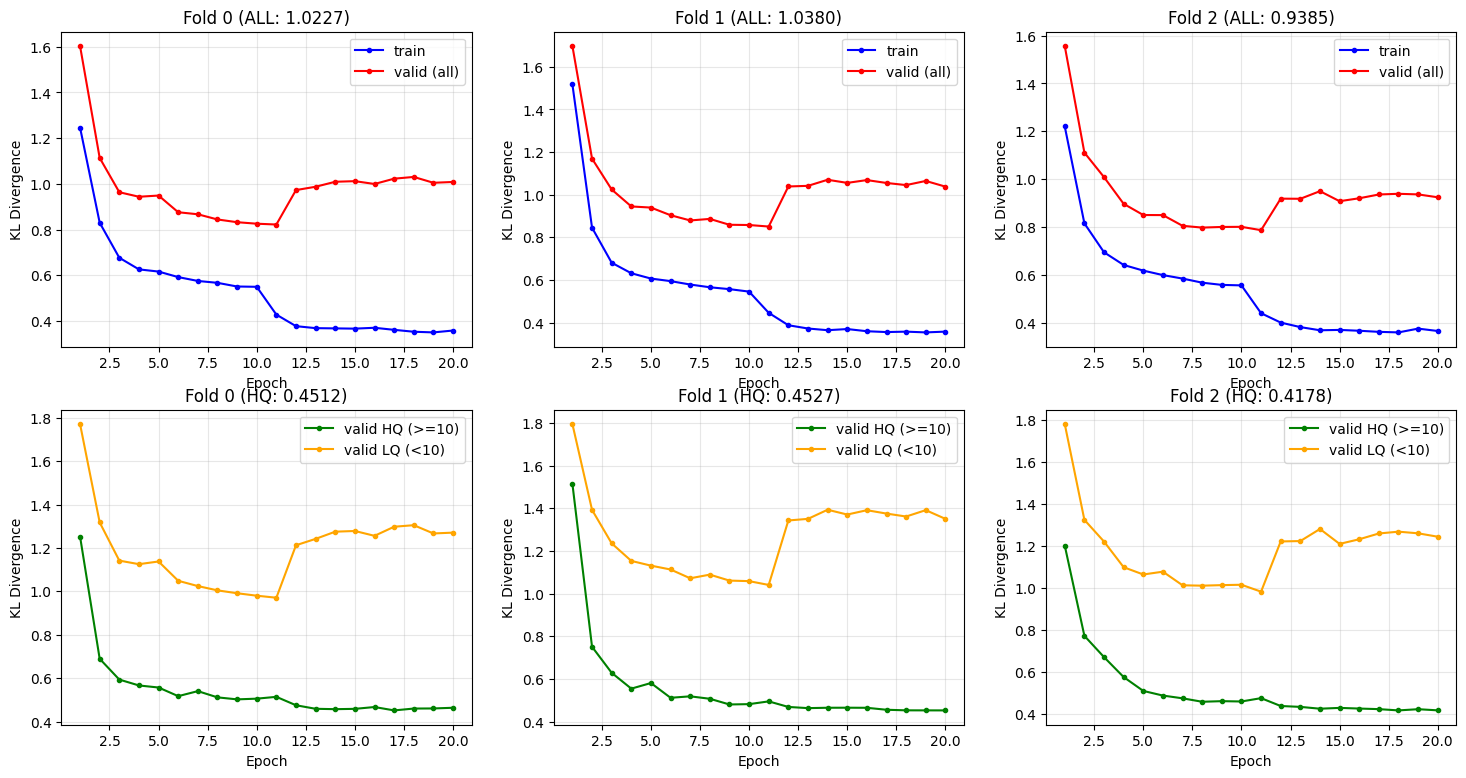

In [20]:
n_folds_done = len(all_histories)
fig, axes = plt.subplots(2, n_folds_done, figsize=(6*n_folds_done, 9))
if n_folds_done == 1:
    axes = axes.reshape(-1, 1)

for col, (fold, hist) in enumerate(all_histories.items()):
    epochs_range = range(1, len(hist["train_loss"]) + 1)

    # Top row: train vs val (all)
    ax = axes[0, col]
    ax.plot(epochs_range, hist["train_loss"], "b-o", markersize=3, label="train")
    ax.plot(epochs_range, hist["val_loss"], "r-o", markersize=3, label="valid (all)")
    ax.set_title(f"Fold {fold} (ALL: {fold_results[fold]['all']:.4f})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("KL Divergence")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Bottom row: HQ vs LQ
    ax = axes[1, col]
    ax.plot(epochs_range, hist["val_loss_hq"], "g-o", markersize=3, label="valid HQ (>=10)")
    ax.plot(epochs_range, hist["val_loss_lq"], "orange", marker="o", markersize=3, label="valid LQ (<10)")
    ax.set_title(f"Fold {fold} (HQ: {fold_results[fold]['hq']:.4f})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("KL Divergence")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f"CV: ALL={cv_all:.4f}, HQ={cv_hq:.4f} (LB estimate)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# 🧪 | Prediction (Ensemble of All Folds)

Load the best checkpoint from each fold, predict on test set,
then average the probabilities. This is the standard Kaggle
submission strategy for cross-validated models.

In [21]:
# Build test DataLoader
test_dataset = HMSDataset(test_df, mode="test", augment=False)
test_loader = DataLoader(
    test_dataset,
    batch_size=min(CFG.batch_size, len(test_df)),
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=False,
)
print(f"Test samples: {len(test_dataset)} | Test batches: {len(test_loader)}")

Test samples: 1 | Test batches: 1


## Run Inference Across All Folds

In [22]:
@torch.no_grad()
def predict(model, loader, device, use_amp=CFG.use_amp):
    """Run inference. Returns numpy predictions."""
    model.eval()
    all_preds = []
    for eeg, stats in tqdm(loader, desc="Predicting"):
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        with autocast(enabled=use_amp):
            preds = model(eeg, stats)
        all_preds.append(preds.cpu().numpy())
    return np.concatenate(all_preds, axis=0)


# Predict with each fold's best model and average
all_fold_preds = []

for fold in CFG.run_folds:
    ckpt_path = str(MODELS_DIR / f"best_model_fold{fold}.pt")
    if not Path(ckpt_path).exists():
        print(f"  ⚠ Fold {fold} checkpoint not found, skipping")
        continue

    print(f"\nFold {fold}:")
    gc.collect()
    torch.cuda.empty_cache()

    model = SpectrogramModel(CFG).to(CFG.device)
    ckpt = torch.load(ckpt_path, map_location=CFG.device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"  Loaded: stage={ckpt.get('stage','?')}, val_loss={ckpt['val_loss']:.4f}")

    fold_preds = predict(model, test_loader, CFG.device)
    all_fold_preds.append(fold_preds)
    np.save(str(RESULTS_DIR / f"pytorch_preds_fold{fold}.npy"), fold_preds)
    print(f"  ✓ Predictions saved ({fold_preds.shape})")

    del model
    gc.collect()
    torch.cuda.empty_cache()

# Average across folds
preds = np.mean(all_fold_preds, axis=0)
print(f"\n✓ Ensemble of {len(all_fold_preds)} folds")
print(f"  Predictions shape: {preds.shape}")
print(f"  Prob sum check: {preds[0].sum():.4f}")


Fold 0:
Freq resolution: 1.56 Hz/bin, keeping 13 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0029 seconds
STFT kernels created, time used = 0.0014 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 256
Input image shape: [3, 208, T]
  Loaded: stage=2, val_loss=1.0227


Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

/var/tmp/ipykernel_714870/4211528771.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


...

  ✓ Predictions saved ((1, 6))

Fold 2:
Freq resolution: 1.56 Hz/bin, keeping 13 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0030 seconds
STFT kernels created, time used = 0.0013 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 256
Input image shape: [3, 208, T]
  Loaded: stage=2, val_loss=0.9385


Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Predictions saved ((1, 6))
  ⚠ Fold 3 checkpoint not found, skipping
  ⚠ Fold 4 checkpoint not found, skipping

✓ Ensemble of 3 folds
  Predictions shape: (1, 6)
  Prob sum check: 1.0000


# 📩 | Submission

In [23]:
target_cols = [x.lower() + "_vote" for x in CFG.class_names]
pred_df = test_df[["eeg_id"]].copy()
pred_df[target_cols] = preds.tolist()

# Merge with sample submission
sub_df = pd.read_csv(BASE_PATH / "sample_submission.csv")
sub_df = sub_df[["eeg_id"]].copy()
sub_df = sub_df.merge(pred_df, on="eeg_id", how="left")

submission_path = str(RESULTS_DIR / "submission.csv")
sub_df.to_csv(submission_path, index=False)
print(f"✓ Submission saved to: {submission_path}")
print(f"  Ensemble of {len(all_fold_preds)} fold predictions")
print(f"\nSubmission preview:")
print(sub_df.head())

✓ Submission saved to: /home/littl/ECE247A_Final_Project/AL/AL_model/results/submission.csv
  Ensemble of 3 fold predictions

Submission preview:
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  3911565283      0.017139  0.050312   0.01617   0.161908   0.188869   

   other_vote  
0    0.565602  


# 🔀 | Ensembling with Keras Predictions (Optional)

If you ran the Keras notebook, you can blend PyTorch + Keras predictions
for an even stronger submission.

In [24]:
# Uncomment to ensemble with Keras

# keras_preds = np.load(str(RESULTS_DIR / "keras_preds.npy"))
# pytorch_preds = preds  # already averaged across folds
# blend = 0.5 * keras_preds + 0.5 * pytorch_preds
# blend_df = test_df[["eeg_id"]].copy()
# blend_df[target_cols] = blend.tolist()
# blend_df.to_csv(str(RESULTS_DIR / "submission_blend.csv"), index=False)
# print("✓ Blended submission saved")

# 🔀 | Ensembling with Keras Predictions (Optional)

If you ran the Keras notebook, you can ensemble predictions from both.
Just save Keras predictions by adding this to the Keras notebook after `model.predict()`:
```python
np.save('results/keras_preds_fold0.npy', preds)
```

In [25]:
# Uncomment to ensemble

# keras_path = RESULTS_DIR / "keras_preds_fold0.npy"
# pytorch_path = RESULTS_DIR / f"pytorch_preds_fold{CFG.fold}.npy"
#
# if keras_path.exists():
#     keras_preds = np.load(str(keras_path))
#     pytorch_preds = np.load(str(pytorch_path))
#
#     # Adjust weights based on val_loss (lower loss → higher weight)
#     w_keras, w_pytorch = 0.3, 0.7
#     ensemble = w_keras * keras_preds + w_pytorch * pytorch_preds
#
#     ens_df = sub_df[["eeg_id"]].copy()
#     ens_df[target_cols] = ensemble.tolist()
#     ens_df.to_csv(str(RESULTS_DIR / "submission_ensemble.csv"), index=False)
#     print("✓ Ensemble submission saved")
# else:
#     print(f"Keras predictions not found at {keras_path}")
#     print("Add np.save('results/keras_preds_fold0.npy', preds) to Keras notebook")

# 📊 | Inspect Learned STFT (Optional)

One advantage of trainable STFT: we can see what the model learned.

Freq resolution: 1.56 Hz/bin, keeping 13 bins (0-20.0 Hz)
STFT kernels created, time used = 0.0028 seconds
STFT kernels created, time used = 0.0012 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 256
Input image shape: [3, 208, T]
STFT kernel shape: (65, 1, 128)


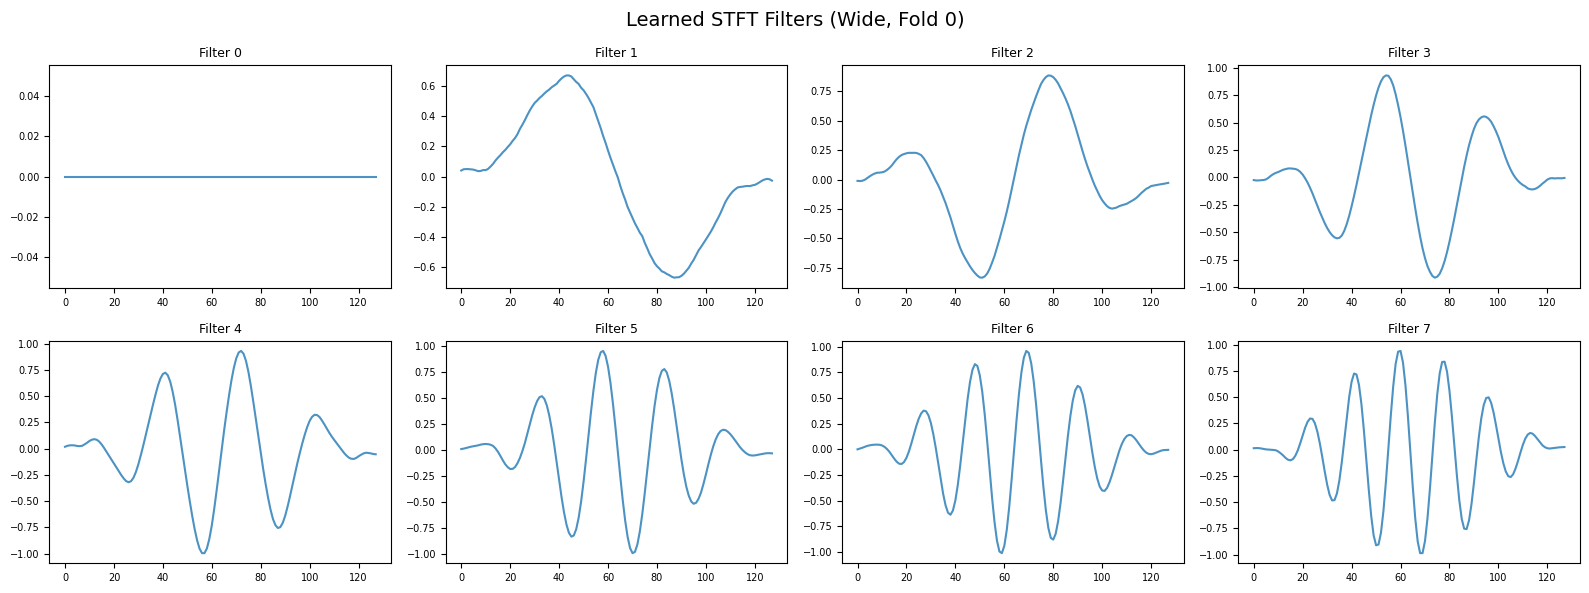

In [27]:
if CFG.trainable_stft:
    try:
        # Reload best model from fold 0 to inspect STFT
        ckpt = torch.load(str(MODELS_DIR / "best_model_fold0.pt"), map_location="cpu")
        model_viz = SpectrogramModel(CFG)
        model_viz.load_state_dict(ckpt["model_state_dict"])
        
        learned = model_viz.stft_wide.wsin.detach().cpu().numpy()
        print(f"STFT kernel shape: {learned.shape}")

        fig, axes = plt.subplots(2, 4, figsize=(16, 6))
        for i, ax in enumerate(axes.flat):
            if i < min(8, learned.shape[0]):
                ax.plot(learned[i, 0, :], alpha=0.8)
                ax.set_title(f"Filter {i}", fontsize=9)
                ax.tick_params(labelsize=7)
        plt.suptitle("Learned STFT Filters (Wide, Fold 0)", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        del model_viz
        gc.collect()
    except Exception as e:
        print(f"Could not visualize: {e}")

# 📌 | Reference
* [HMS-HBAC: ResNet34d Baseline [Training]](https://www.kaggle.com/code/ttahara/hms-hbac-resnet34d-baseline-training)
* [EfficientNetB2 Starter - [LB 0.57]](https://www.kaggle.com/code/cdeotte/efficientnetb2-starter-lb-0-57)
* [nnAudio Documentation](https://kinwaicheuk.github.io/nnAudio/)
* [timm Model Zoo](https://huggingface.co/timm)